# Regression Analysis — Tenerife & Gran Canaria
## Climate Mortality Project | Phase 6 — Regression Modeling

This notebook models the relationship between calima (Saharan dust) events and weekly
mortality in Tenerife (TFE) and Gran Canaria (GC), the two Canary Islands with the
strongest and most reliable calima-mortality signal.

### Scope
- **Islands:** TFE + GC (island-level models, not pooled)
- **Period:** 2016–2025
- **Target:** `deaths_week` (all-cause weekly mortality)
- **Key predictor:** `calima_proxy_level` (v2 proxy: no_calima / moderate / intense / extreme)

### Notebook structure
1. Data load & audit
2. Feature engineering (lags, seasonality dummies, calima encoding)
3. EDA for regression (scatter plots, correlations, outliers)
4. Simple linear regression — calima_proxy_score ~ deaths_week
5. Multiple regression — adding confounders (temperature, humidity, PM10)
6. Model diagnostics & interpretation
7. Results summary

# 1. Data load and audit

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

ROOT = Path(r'C:\Users\fdora\RA_Career\Projects\climate_mortality')
sys.path.insert(0, str(ROOT))

from src.utils.d25_nb_utils import (
    autosave_fig, save_table,
)
REPORTS_DIR = ROOT / "reports" / "ccaa"
TAB_DIR = REPORTS_DIR / "tables" 
FIG_DIR = REPORTS_DIR / "figures"
TAB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path().resolve().parents[1]  # project root from CCAA/regression/
DATA = BASE / "data/processed/provinces/regression_tfe_gc_2016_2025.parquet"

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA)

# ── Structure ──────────────────────────────────────────────────────────────
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Period: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print(f"Islands: {df['island'].unique().tolist()}")
print(f"Rows per island:\n{df['island'].value_counts().to_string()}")

# ── Dtypes ─────────────────────────────────────────────────────────────────
print("\n── Column types ──")
print(df.dtypes.to_string())

# ── Missing values ─────────────────────────────────────────────────────────
print("\n── Missing values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
audit = audit[audit["n_missing"] > 0]
print(audit.to_string() if not audit.empty else "No missing values")

# ── Calima proxy distribution ───────────────────────────────────────────────
print("\n── calima_proxy_level distribution (per island) ──")
print(df.groupby(["island", "calima_proxy_level"]).size().unstack(fill_value=0).to_string())

# ── Deaths summary ─────────────────────────────────────────────────────────
print("\n── deaths_week summary (per island) ──")
print(df.groupby("island")["deaths_week"].describe().round(2).to_string())

Shape: 1046 rows × 15 columns
Period: 2015-12-28 → 2025-12-29
Islands: ['gran_canaria', 'tenerife']
Rows per island:
island
gran_canaria    523
tenerife        523

── Column types ──
week_start               datetime64[ns]
year                              int32
island                           object
deaths_week                     float64
temp_c_mean                     float64
tmax_c_mean                     float64
tmin_c_mean                     float64
humidity_mean                   float64
prec_sum                        float64
PM10                            float64
PM2.5                           float64
low_vis_any_days_week           float64
vis_min_m_week                  float64
calima_proxy_score              float64
calima_proxy_level               object

── Missing values ──
                       n_missing  pct_missing
deaths_week                    2         0.19
PM10                          19         1.82
PM2.5                         30         2.87
low_vis_an

In [2]:
# ── Missing values audit ───────────────────────────────────────────────────

# 1. Locate deaths_week null
print("── deaths_week nulls ──")
print(df[df["deaths_week"].isnull()][["week_start", "year", "island", "deaths_week"]].to_string())

# 2. Nulls for PM10/PM2.5/vis are same rows or different?
print("\n── Overlap: ¿mismas filas? ──")
null_deaths = set(df[df["deaths_week"].isnull()].index)
null_pm10   = set(df[df["PM10"].isnull()].index)
null_pm25   = set(df[df["PM2.5"].isnull()].index)
null_vis    = set(df[df["low_vis_any_days_week"].isnull()].index)

print(f"deaths_week nulls:        {sorted(null_deaths)}")
print(f"PM10 nulls overlap:       {null_pm10 & null_deaths}")
print(f"PM2.5 nulls overlap:      {null_pm25 & null_deaths}")
print(f"vis nulls overlap:        {null_vis & null_deaths}")

# 3. When occurs nulls for vis/PM? Are they temporary concentrated?
print("\n── PM10 nulls — distribución temporal ──")
print(df[df["PM10"].isnull()][["week_start", "year", "island"]].to_string())

print("\n── vis nulls — distribución temporal ──")
print(df[df["low_vis_any_days_week"].isnull()][["week_start", "year", "island"]].to_string())

── deaths_week nulls ──
    week_start  year        island  deaths_week
0   2015-12-28  2015  gran_canaria          NaN
523 2015-12-28  2015      tenerife          NaN

── Overlap: ¿mismas filas? ──
deaths_week nulls:        [0, 523]
PM10 nulls overlap:       set()
PM2.5 nulls overlap:      set()
vis nulls overlap:        set()

── PM10 nulls — distribución temporal ──
     week_start  year    island
995  2025-01-13  2025  tenerife
996  2025-01-20  2025  tenerife
1003 2025-03-10  2025  tenerife
1005 2025-03-24  2025  tenerife
1006 2025-03-31  2025  tenerife
1014 2025-05-26  2025  tenerife
1015 2025-06-02  2025  tenerife
1016 2025-06-09  2025  tenerife
1017 2025-06-16  2025  tenerife
1019 2025-06-30  2025  tenerife
1026 2025-08-18  2025  tenerife
1028 2025-09-01  2025  tenerife
1029 2025-09-08  2025  tenerife
1030 2025-09-15  2025  tenerife
1037 2025-11-03  2025  tenerife
1039 2025-11-17  2025  tenerife
1040 2025-11-24  2025  tenerife
1041 2025-12-01  2025  tenerife
1042 2025-12-08  202

In [3]:
# ── Cleaning ───────────────────────────────────────────────────────────────

# 1. Drop rows with no deaths_week (starter week 2015-12-28)
df = df[df["deaths_week"].notna()].reset_index(drop=True)
print(f"After dropping deaths_week nulls: {df.shape[0]} rows")

# 2. Imputate PM10, PM2.5, vis with median by island.
cols_to_impute = ["PM10", "PM2.5", "low_vis_any_days_week", "vis_min_m_week"]

for col in cols_to_impute:
    medians = df.groupby("island")[col].median()
    for island in df["island"].unique():
        mask = (df["island"] == island) & (df[col].isnull())
        df.loc[mask, col] = medians[island]
    print(f"Imputed {col}: medians → {medians.round(2).to_dict()}")

# 3. Final check
print("\n── Post-cleaning missing check ──")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if not missing.empty else "✅ No missing values")
print(f"\nFinal shape: {df.shape[0]} rows × {df.shape[1]} columns")

After dropping deaths_week nulls: 1044 rows
Imputed PM10: medians → {'gran_canaria': 39.64, 'tenerife': 34.43}
Imputed PM2.5: medians → {'gran_canaria': 15.57, 'tenerife': 11.86}
Imputed low_vis_any_days_week: medians → {'gran_canaria': 2.0, 'tenerife': 0.0}
Imputed vis_min_m_week: medians → {'gran_canaria': 14000.0, 'tenerife': 25000.0}

── Post-cleaning missing check ──
✅ No missing values

Final shape: 1044 rows × 15 columns


# 2. Feature engineering (lags, seasonality dummies, calima encoding)

In [4]:
# ── Feature Engineering ────────────────────────────────────────────────────

# 1. Ordinal encoding calima_proxy_level
calima_order = {"no_calima": 0, "possible": 1, "probable": 2, "intense": 3}
df["calima_ordinal"] = df["calima_proxy_level"].map(calima_order)

print("── calima_ordinal encoding ──")
print(df.groupby(["island", "calima_proxy_level", "calima_ordinal"]).size().to_string())

# 2. Lags de calima_ordinal por isla (lag-1, lag-2)
df = df.sort_values(["island", "week_start"]).reset_index(drop=True)

df["calima_lag1"] = df.groupby("island")["calima_ordinal"].shift(1)
df["calima_lag2"] = df.groupby("island")["calima_ordinal"].shift(2)

print(f"\n── Lags introduced nulls ──")
print(f"calima_lag1 nulls: {df['calima_lag1'].isnull().sum()}")
print(f"calima_lag2 nulls: {df['calima_lag2'].isnull().sum()}")

# 3. Trimestre dummies
df["quarter"] = df["week_start"].dt.quarter
dummies = pd.get_dummies(df["quarter"], prefix="Q", drop_first=False).astype(int)
df = pd.concat([df, dummies], axis=1)

print("\n── Quarter dummies ──")
print(df[["island", "week_start", "quarter", "Q_1", "Q_2", "Q_3", "Q_4"]].head(8).to_string())

# 4. Resumen features finales
print(f"\n── Final shape after feature engineering: {df.shape} ──")
print(df.dtypes.to_string())

── calima_ordinal encoding ──
island        calima_proxy_level  calima_ordinal
gran_canaria  intense             3                  46
              no_calima           0                 284
              possible            1                 129
              probable            2                  63
tenerife      intense             3                  49
              no_calima           0                 355
              possible            1                  82
              probable            2                  36

── Lags introduced nulls ──
calima_lag1 nulls: 2
calima_lag2 nulls: 4

── Quarter dummies ──
         island week_start  quarter  Q_1  Q_2  Q_3  Q_4
0  gran_canaria 2016-01-04        1    1    0    0    0
1  gran_canaria 2016-01-11        1    1    0    0    0
2  gran_canaria 2016-01-18        1    1    0    0    0
3  gran_canaria 2016-01-25        1    1    0    0    0
4  gran_canaria 2016-02-01        1    1    0    0    0
5  gran_canaria 2016-02-08        1    1   

# 3. EDA for regression (scatter plots, correlations, outliers)

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\eda_regression_tfe_gc.png


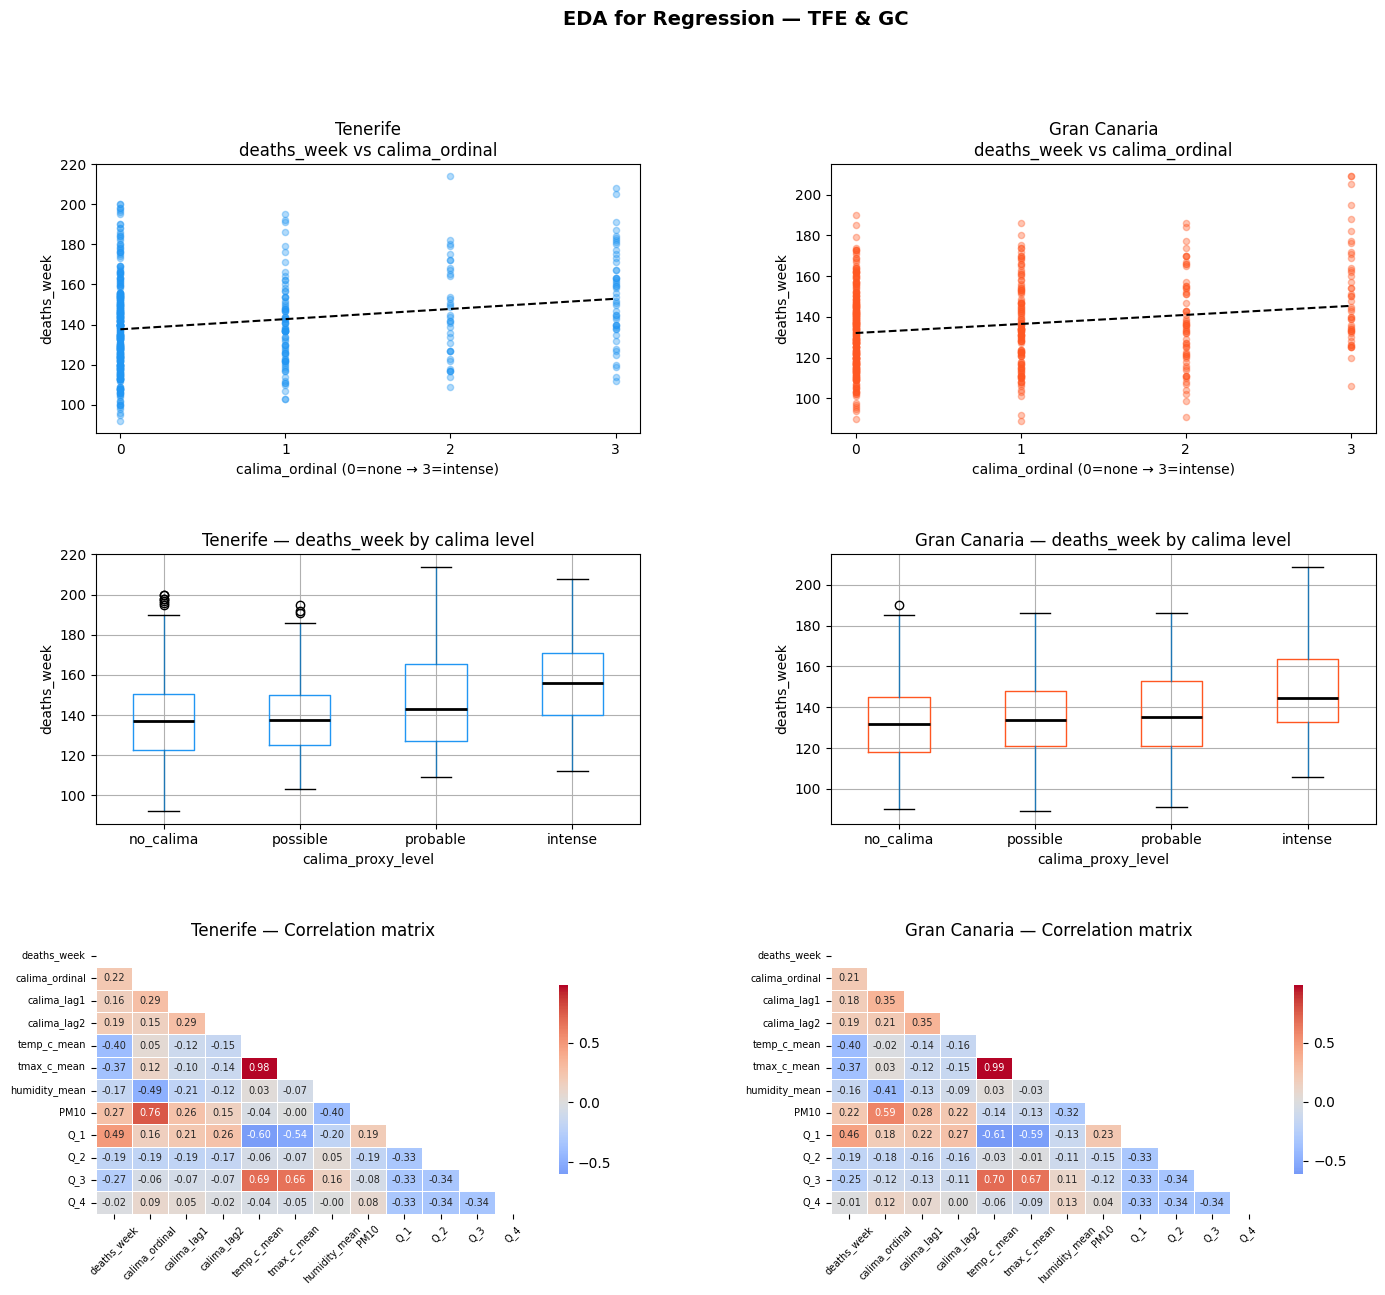


── Mean deaths_week by island + calima_proxy_level ──
                                   mean    std  count
island       calima_proxy_level                      
gran_canaria intense             150.80  24.61     46
             no_calima           132.84  18.78    284
             possible            135.06  20.28    129
             probable            136.57  22.39     63
tenerife     intense             155.37  22.76     49
             no_calima           138.18  21.68    355
             possible            139.60  20.33     82
             probable            146.31  24.26     36


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────
ISLANDS = ["tenerife", "gran_canaria"]
COLORS  = {"tenerife": "#2196F3", "gran_canaria": "#FF5722"}
LEVEL_ORDER = ["no_calima", "possible", "probable", "intense"]

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1-2: Scatter deaths_week vs calima_ordinal ────────────────────────
for i, island in enumerate(ISLANDS):
    ax = fig.add_subplot(gs[0, i])
    d  = df[df["island"] == island].dropna(subset=["calima_lag1"])
    ax.scatter(d["calima_ordinal"], d["deaths_week"],
               alpha=0.35, s=20, color=COLORS[island])
    # Trend line
    z = np.polyfit(d["calima_ordinal"], d["deaths_week"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 3, 100)
    ax.plot(x_line, p(x_line), color="black", linewidth=1.5, linestyle="--")
    ax.set_title(f"{island.replace('_', ' ').title()}\ndeaths_week vs calima_ordinal")
    ax.set_xlabel("calima_ordinal (0=none → 3=intense)")
    ax.set_ylabel("deaths_week")
    ax.set_xticks([0, 1, 2, 3])

# ── Plot 3-4: Boxplot deaths_week por calima_proxy_level ──────────────────
for i, island in enumerate(ISLANDS):
    ax = fig.add_subplot(gs[1, i])
    d  = df[df["island"] == island].copy()
    d["calima_proxy_level"] = pd.Categorical(d["calima_proxy_level"],
                                              categories=LEVEL_ORDER, ordered=True)
    d.boxplot(column="deaths_week", by="calima_proxy_level", ax=ax,
              boxprops=dict(color=COLORS[island]),
              medianprops=dict(color="black", linewidth=2))
    ax.set_title(f"{island.replace('_', ' ').title()}\ndeaths_week by calima level")
    ax.set_xlabel("calima_proxy_level")
    ax.set_ylabel("deaths_week")
    plt.sca(ax)
    plt.title(f"{island.replace('_', ' ').title()} — deaths_week by calima level")

# ── Plot 5: Correlation heatmap (TFE) ─────────────────────────────────────
CORR_COLS = ["deaths_week", "calima_ordinal", "calima_lag1", "calima_lag2",
             "temp_c_mean", "tmax_c_mean", "humidity_mean", "PM10", "Q_1", "Q_2", "Q_3", "Q_4"]

for i, island in enumerate(ISLANDS):
    ax  = fig.add_subplot(gs[2, i])
    d   = df[df["island"] == island][CORR_COLS].dropna()
    corr = d.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.4, cbar_kws={"shrink": 0.7})
    ax.set_title(f"{island.replace('_', ' ').title()} — Correlation matrix")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

fig.suptitle("EDA for Regression — TFE & GC", fontsize=14, fontweight="bold", y=1.01)
autosave_fig(FIG_DIR / "eda_regression_tfe_gc.png")

# plt.savefig("eda_regression_tfe_gc.png", dpi=150, bbox_inches="tight")
plt.show()
# print("✅ Plot saved: eda_regression_tfe_gc.png")

# ── Mean deaths by calima level (tabla resumen) ────────────────────────────
print("\n── Mean deaths_week by island + calima_proxy_level ──")
summary = (df.groupby(["island", "calima_proxy_level"])["deaths_week"]
             .agg(["mean", "std", "count"])
             .round(2))
print(summary.to_string())

## EDA Findings

### Scatter plots & trend
Both islands show a positive slope — higher `calima_ordinal` associates with higher
`deaths_week`. Signal is real but noisy, as expected with weekly all-cause mortality data.

### Boxplots by calima level
- **Tenerife:** median rises progressively from `no_calima` → `intense` (clearest pattern)
- **Gran Canaria:** intermediary levels (possible, probable) are nearly flat;
  the jump is concentrated at `intense`

### Mean deaths by calima level
| Island | no_calima | possible | probable | intense | Δ intense vs no_calima |
|---|---|---|---|---|---|
| Tenerife | 138.2 | 139.6 | 146.3 | 155.4 | **+17.2 (+12.4%)** |
| Gran Canaria | 132.8 | 135.1 | 136.6 | 150.8 | **+18.0 (+13.5%)** |

### Correlation matrix highlights
- `calima_ordinal` → `deaths_week`: r = 0.22 (TFE), 0.21 (GC) — moderate, consistent
- `calima_lag1/lag2`: slightly lower (0.16–0.19) — effect is primarily contemporaneous
- `Q_1` → `deaths_week`: r = 0.49 (TFE), 0.46 (GC) — strong winter seasonality, must be controlled
- `temp_c_mean` → `deaths_week`: r = −0.40 both islands — cold = more deaths, classic confounder

### Conclusion
Dataset is ready for modeling. Calima signal exists but seasonality (Q_1) and
temperature must be controlled in the multiple regression to isolate the true effect.

# 4. Simple linear regression — calima_proxy_score ~ deaths_week

In [6]:
from scipy import stats

print("=" * 60)
print("SIMPLE LINEAR REGRESSION — calima_ordinal ~ deaths_week")
print("=" * 60)

for island in ISLANDS:
    d = df[df["island"] == island].dropna(subset=["calima_ordinal", "deaths_week"])

    x = d["calima_ordinal"]
    y = d["deaths_week"]

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    print(f"\n── {island.replace('_', ' ').title()} ──")
    print(f"  β  (slope):     {slope:.4f}  → +{slope:.2f} deaths per calima level increase")
    print(f"  α  (intercept): {intercept:.4f}")
    print(f"  R²:             {r_squared:.4f}")
    print(f"  p-value:        {p_value:.4e}")
    print(f"  std_err:        {std_err:.4f}")
    print(f"  Significant:    {'✅ Yes (p < 0.05)' if p_value < 0.05 else '❌ No'}")

SIMPLE LINEAR REGRESSION — calima_ordinal ~ deaths_week

── Tenerife ──
  β  (slope):     5.0796  → +5.08 deaths per calima level increase
  α  (intercept): 137.6476
  R²:             0.0491
  p-value:        3.1473e-07
  std_err:        0.9802
  Significant:    ✅ Yes (p < 0.05)

── Gran Canaria ──
  β  (slope):     4.4506  → +4.45 deaths per calima level increase
  α  (intercept): 132.0707
  R²:             0.0442
  p-value:        1.2615e-06
  std_err:        0.9077
  Significant:    ✅ Yes (p < 0.05)


## Simple Linear Regression — Results

### Model: deaths_week ~ calima_ordinal

| Island | β (slope) | α (intercept) | R² | p-value |
|---|---|---|---|---|
| Tenerife | +5.08 | 137.65 | 0.049 | 3.15e-07 |
| Gran Canaria | +4.45 | 132.07 | 0.044 | 1.26e-06 |

### Interpretation
- Each calima level increase associates with **+5.08 deaths/week (TFE)** and **+4.45 deaths/week (GC)**
- At `intense` (level 3): predicted mortality ≈ 153 (TFE), 145 (GC) — consistent with observed means
- Both models are **highly significant** (p < 0.001)

### R² note
R² ~0.05 is expected — weekly all-cause mortality has high intrinsic variance.
Calima alone explains ~5% of variance. The signal is real but confounders
(seasonality, temperature) will be added in the multiple regression model.

# 5.Multiple regression — adding confounders (temperature, humidity, PM10)

In [7]:
import statsmodels.formula.api as smf

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION")
print("Model: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3")
print("(Q_4 omitted as reference category)")
print("=" * 60)

results = {}

for island in ISLANDS:
    d = df[df["island"] == island].dropna(subset=["calima_ordinal", "deaths_week",
                                                    "temp_c_mean", "Q_1", "Q_2", "Q_3"])

    model  = smf.ols("deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3", data=d).fit()
    results[island] = model

    print(f"\n── {island.replace('_', ' ').title()} ──")
    print(f"  R²:          {model.rsquared:.4f}")
    print(f"  Adj. R²:     {model.rsquared_adj:.4f}")
    print(f"  F-statistic: {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})")
    print(f"\n  Coefficients:")
    summary = model.params.to_frame("β").join(model.pvalues.to_frame("p-value"))
    summary["significant"] = summary["p-value"].apply(lambda p: "✅" if p < 0.05 else "❌")
    summary["β"]       = summary["β"].round(4)
    summary["p-value"] = summary["p-value"].apply(lambda p: f"{p:.4e}")
    print(summary.to_string())

MULTIPLE LINEAR REGRESSION
Model: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3
(Q_4 omitted as reference category)

── Tenerife ──
  R²:          0.2917
  Adj. R²:     0.2848
  F-statistic: 42.50  (p = 1.15e-36)

  Coefficients:
                       β     p-value significant
Intercept       173.5758  3.8468e-44           ✅
calima_ordinal    3.7926  2.9038e-05           ✅
temp_c_mean      -1.6675  1.2901e-03           ✅
Q_1              14.9768  5.5067e-08           ✅
Q_2              -5.0622  3.3394e-02           ✅
Q_3              -2.8408  3.3416e-01           ❌

── Gran Canaria ──
  R²:          0.2576
  Adj. R²:     0.2504
  F-statistic: 35.81  (p = 1.74e-31)

  Coefficients:
                       β     p-value significant
Intercept       170.8293  5.1645e-45           ✅
calima_ordinal    2.9762  5.1665e-04           ✅
temp_c_mean      -1.7841  5.3347e-04           ✅
Q_1              11.6467  8.1751e-06           ✅
Q_2              -4.9592  2.9180e-02           ✅


## Multiple Linear Regression — Results

### Model: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3
(Q_4 as reference category)

| Metric | Tenerife | Gran Canaria |
|---|---|---|
| R² | 0.292 | 0.258 |
| Adj. R² | 0.285 | 0.250 |
| F-statistic | 42.50 (p = 1.15e-36) | 35.81 (p = 1.74e-31) |

### Coefficients

| Predictor | β TFE | β GC | Significant |
|---|---|---|---|
| Intercept | 173.58 | 170.83 | ✅ |
| calima_ordinal | +3.79 | +2.98 | ✅ |
| temp_c_mean | −1.67 | −1.78 | ✅ |
| Q_1 | +14.98 | +11.65 | ✅ |
| Q_2 | −5.06 | −4.96 | ✅ |
| Q_3 | −2.84 | −1.54 | ❌ |

### Key findings
- **R² improves from ~0.05 → ~0.29** after controlling for temperature and seasonality (6x variance explained)
- **calima_ordinal β decreases** from 5.08 → 3.79 (TFE) and 4.45 → 2.98 (GC) — part of the
  crude effect was confounded by temperature and season; the adjusted effect remains **significant**
- **temp_c_mean:** each +1°C associates with ~1.7 fewer deaths/week — classic cold-mortality effect
- **Q_1 (winter):** adds +12–15 deaths/week over Q_4 — dominant confounder confirmed
- **Q_3 (summer):** not significant in either island — summer mortality does not differ from Q_4

In [8]:
print("=" * 60)
print("MODEL COMPARISON")
print("Model 1: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3")
print("Model 2: Model 1 + humidity_mean + PM10")
print("=" * 60)

results_m2 = {}

for island in ISLANDS:
    d = df[df["island"] == island].dropna(subset=["calima_ordinal", "deaths_week",
                                                    "temp_c_mean", "Q_1", "Q_2", "Q_3",
                                                    "humidity_mean", "PM10"])

    m1 = results[island]  # ya calculado en celda 10
    m2 = smf.ols("deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3 + humidity_mean + PM10",
                 data=d).fit()
    results_m2[island] = m2

    print(f"\n── {island.replace('_', ' ').title()} ──")
    print(f"{'Metric':<20} {'Model 1':>10} {'Model 2':>10}")
    print("-" * 42)
    print(f"{'R²':<20} {m1.rsquared:>10.4f} {m2.rsquared:>10.4f}")
    print(f"{'Adj. R²':<20} {m1.rsquared_adj:>10.4f} {m2.rsquared_adj:>10.4f}")
    print(f"{'AIC':<20} {m1.aic:>10.2f} {m2.aic:>10.2f}")
    print(f"{'BIC':<20} {m1.bic:>10.2f} {m2.bic:>10.2f}")

    print(f"\n  Model 2 Coefficients:")
    summary = m2.params.to_frame("β").join(m2.pvalues.to_frame("p-value"))
    summary["significant"] = summary["p-value"].apply(lambda p: "✅" if p < 0.05 else "❌")
    summary["β"]       = summary["β"].round(4)
    summary["p-value"] = summary["p-value"].apply(lambda p: f"{p:.4e}")
    print(summary.to_string())

MODEL COMPARISON
Model 1: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3
Model 2: Model 1 + humidity_mean + PM10

── Tenerife ──
Metric                  Model 1    Model 2
------------------------------------------
R²                       0.2917     0.3008
Adj. R²                  0.2848     0.2913
AIC                     4553.93    4551.18
BIC                     4579.47    4585.24

  Model 2 Coefficients:
                       β     p-value significant
Intercept       172.1828  1.8552e-25           ✅
calima_ordinal    1.1270  4.2150e-01           ❌
temp_c_mean      -1.5803  2.4722e-03           ✅
Q_1              14.7920  1.0557e-07           ✅
Q_2              -4.8269  4.2109e-02           ✅
Q_3              -2.8758  3.3042e-01           ❌
humidity_mean    -0.0312  8.2819e-01           ❌
PM10              0.0590  1.0602e-02           ✅

── Gran Canaria ──
Metric                  Model 1    Model 2
------------------------------------------
R²                       0.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

print("=" * 60)
print("VARIANCE INFLATION FACTOR (VIF)")
print("Threshold: VIF > 5 = moderate, VIF > 10 = severe collinearity")
print("=" * 60)

FEATURES_M1 = ["calima_ordinal", "temp_c_mean", "Q_1", "Q_2", "Q_3"]
FEATURES_M2 = ["calima_ordinal", "temp_c_mean", "Q_1", "Q_2", "Q_3", "humidity_mean", "PM10"]

for island in ISLANDS:
    d = df[df["island"] == island].dropna(subset=FEATURES_M2 + ["deaths_week"])

    print(f"\n── {island.replace('_', ' ').title()} ──")

    for label, features in [("Model 1", FEATURES_M1), ("Model 2", FEATURES_M2)]:
        X = d[features].copy()
        X.insert(0, "Intercept", 1)
        vif = pd.DataFrame({
            "feature": features,
            "VIF": [variance_inflation_factor(X.values, i+1) for i in range(len(features))]
        }).sort_values("VIF", ascending=False)
        vif["VIF"] = vif["VIF"].round(2)
        vif["flag"] = vif["VIF"].apply(lambda v: "🔴 severe" if v > 10 else ("🟡 moderate" if v > 5 else "✅ ok"))
        print(f"\n  {label}:")
        print(vif.to_string(index=False))

VARIANCE INFLATION FACTOR (VIF)
Threshold: VIF > 5 = moderate, VIF > 10 = severe collinearity

── Tenerife ──

  Model 1:
       feature  VIF flag
   temp_c_mean 2.82 ✅ ok
           Q_3 2.39 ✅ ok
           Q_1 2.01 ✅ ok
           Q_2 1.54 ✅ ok
calima_ordinal 1.12 ✅ ok

  Model 2:
       feature  VIF flag
   temp_c_mean 2.89 ✅ ok
calima_ordinal 2.75 ✅ ok
          PM10 2.44 ✅ ok
           Q_3 2.44 ✅ ok
           Q_1 2.07 ✅ ok
           Q_2 1.55 ✅ ok
 humidity_mean 1.38 ✅ ok

── Gran Canaria ──

  Model 1:
       feature  VIF flag
   temp_c_mean 2.96 ✅ ok
           Q_3 2.56 ✅ ok
           Q_1 2.02 ✅ ok
           Q_2 1.56 ✅ ok
calima_ordinal 1.13 ✅ ok

  Model 2:
       feature  VIF flag
   temp_c_mean 3.00 ✅ ok
           Q_3 2.57 ✅ ok
           Q_1 2.07 ✅ ok
calima_ordinal 1.85 ✅ ok
           Q_2 1.66 ✅ ok
          PM10 1.62 ✅ ok
 humidity_mean 1.30 ✅ ok


## Model Comparison — Results

### Model 1 vs Model 2

| Metric | TFE M1 | TFE M2 | GC M1 | GC M2 |
|---|---|---|---|---|
| R² | 0.292 | 0.301 | 0.258 | 0.265 |
| Adj. R² | 0.285 | 0.291 | 0.250 | 0.255 |
| AIC | 4553.93 | 4551.18 | 4501.41 | 4499.94 |
| BIC | 4579.47 | 4585.24 | 4526.96 | 4534.00 |

### VIF check
All predictors in both models show VIF < 3 — no collinearity detected.

### Why does calima_ordinal lose significance in Model 2?
The drop in calima_ordinal β (3.79 → 1.13 TFE, 2.98 → 1.65 GC) and loss of significance
is not collinearity — it is **partial mediation**:

> calima → ↑ PM10 → ↑ deaths_week

PM10 is a pathway of the calima effect, not an independent confounder. Including it
alongside calima_ordinal causes the model to split the effect across both predictors.

### Model selection
- **Model 1 = primary model** — captures the total calima effect (direct + mediated via PM10)
- **Model 2 = sensitivity analysis** — isolates the direct calima effect excluding the PM10 pathway
- AIC favors M2 marginally, but BIC penalizes the extra predictors — no clear improvement
- For the project objective (quantify calima impact on mortality), **Model 1 is preferred**

# 6. Model Diagnostics & Interpretation
### Model 1: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3

Checking four key OLS assumptions:
1. **Linearity** — Residuals vs Fitted (no systematic pattern expected)
2. **Normality of residuals** — Q-Q plot + Shapiro-Wilk test
3. **Homoscedasticity** — Scale-Location plot (constant variance expected)
4. **Residual distribution** — histogram centered at zero

── Tenerife — Shapiro-Wilk normality test ──
  W = 0.9850, p = 3.3661e-05
  Residuals normal: ❌ No (p < 0.05)

── Gran Canaria — Shapiro-Wilk normality test ──
  W = 0.9909, p = 2.6680e-03
  Residuals normal: ❌ No (p < 0.05)

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\diagnostics_model1_tfe_gc.png


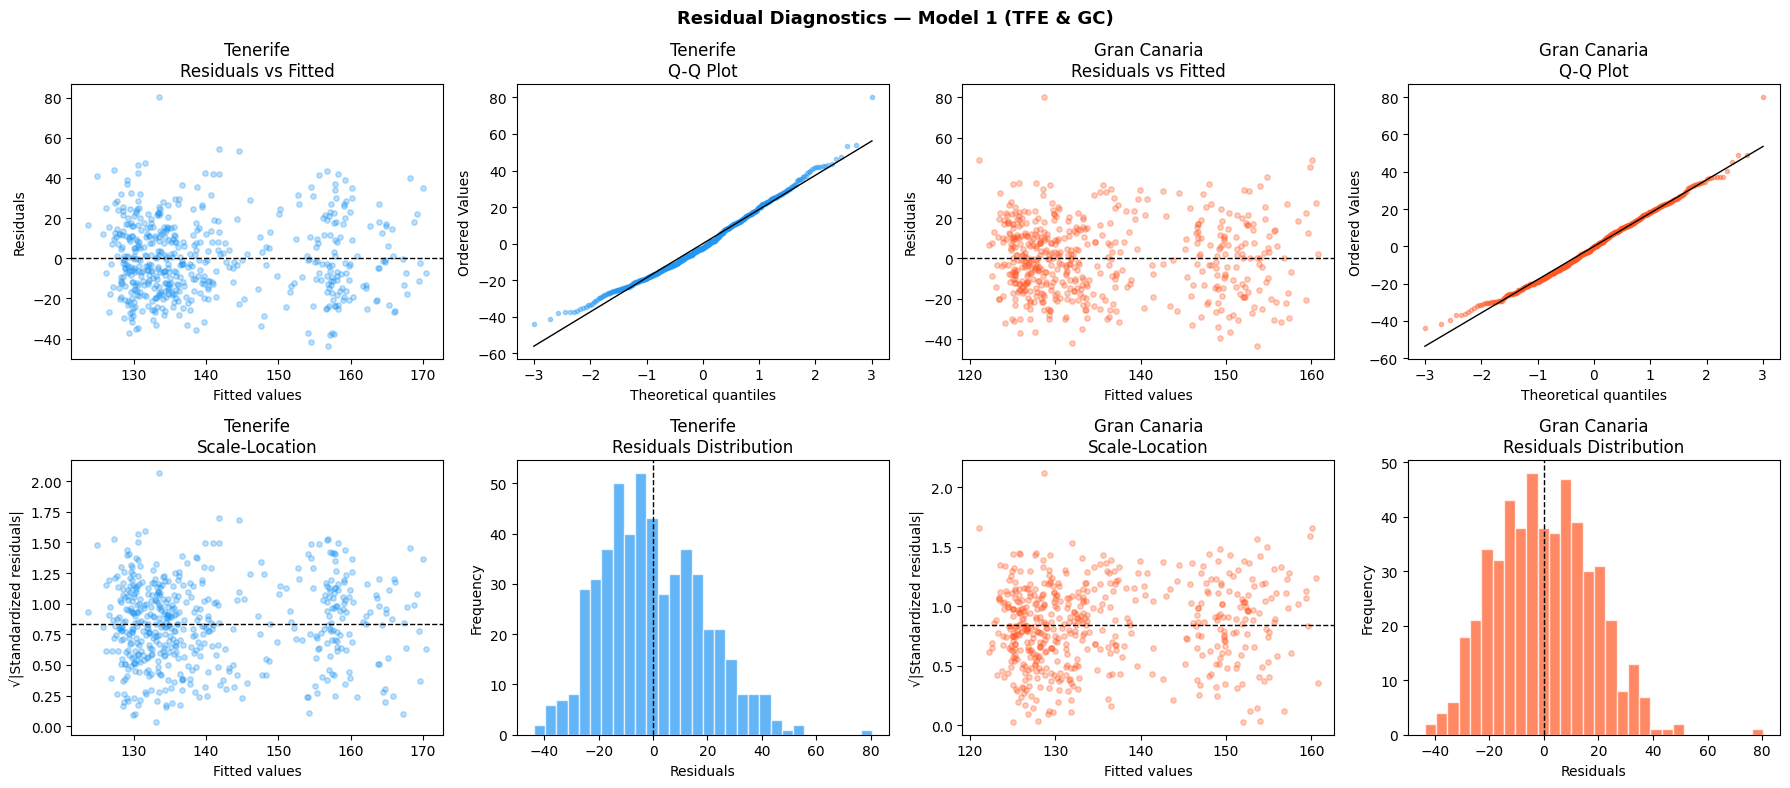

In [10]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Residual Diagnostics — Model 1 (TFE & GC)", fontsize=13, fontweight="bold")

for col, island in enumerate(ISLANDS):
    d       = df[df["island"] == island].dropna(subset=["calima_ordinal", "deaths_week",
                                                         "temp_c_mean", "Q_1", "Q_2", "Q_3"])
    model   = results[island]
    fitted  = model.fittedvalues
    resid   = model.resid
    std_resid = resid / resid.std()

    title_prefix = island.replace("_", " ").title()

    # ── Plot 1: Residuals vs Fitted ────────────────────────────────────────
    ax = axes[0, col * 2]
    ax.scatter(fitted, resid, alpha=0.3, s=15, color=COLORS[island])
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"{title_prefix}\nResiduals vs Fitted")

    # ── Plot 2: Q-Q plot ───────────────────────────────────────────────────
    ax = axes[0, col * 2 + 1]
    scipy_stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix}\nQ-Q Plot")
    ax.get_lines()[0].set(markersize=3, alpha=0.4, color=COLORS[island])
    ax.get_lines()[1].set(color="black", linewidth=1)

    # ── Plot 3: Scale-Location ─────────────────────────────────────────────
    ax = axes[1, col * 2]
    ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=15, color=COLORS[island])
    ax.axhline(np.sqrt(np.abs(std_resid)).mean(), color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("√|Standardized residuals|")
    ax.set_title(f"{title_prefix}\nScale-Location")

    # ── Plot 4: Residuals histogram ────────────────────────────────────────
    ax = axes[1, col * 2 + 1]
    ax.hist(resid, bins=30, color=COLORS[island], alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Residuals")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{title_prefix}\nResiduals Distribution")

    # ── Normality test ─────────────────────────────────────────────────────
    stat, p = scipy_stats.shapiro(resid)
    print(f"── {title_prefix} — Shapiro-Wilk normality test ──")
    print(f"  W = {stat:.4f}, p = {p:.4e}")
    print(f"  Residuals normal: {'✅ Yes (p > 0.05)' if p > 0.05 else '❌ No (p < 0.05)'}\n")

plt.tight_layout()
autosave_fig(FIG_DIR / "diagnostics_model1_tfe_gc.png")
plt.show()

## Model Diagnostics — Findings

### 1. Linearity (Residuals vs Fitted)
Residuals scatter randomly around zero with no systematic pattern — ✅ linearity assumption holds.

### 2. Homoscedasticity (Scale-Location)
Variance is approximately constant across the range of fitted values — ✅ homoscedasticity reasonable.

### 3. Normality of residuals (Q-Q + Shapiro-Wilk)
| Island | Shapiro-Wilk W | p-value | Normal? |
|---|---|---|---|
| Tenerife | 0.9850 | 3.37e-05 | ❌ |
| Gran Canaria | 0.9909 | 2.67e-03 | ❌ |

Q-Q plots show deviation at the tails (heavier than normal), confirmed by Shapiro-Wilk.
However, W > 0.98 in both cases indicates **mild, not severe** departure from normality.

### 4. Residuals distribution
Right-skewed histogram with a longer upper tail — consistent with Q-Q findings.
The left tail (unusually low mortality weeks) suggests weeks with incomplete data
or holiday effects not captured by the model.

### OLS robustness note
With n > 500, OLS estimates remain valid by the Central Limit Theorem.
Mild non-normality of residuals does not invalidate coefficients or inference.
**Model 1 is structurally sound and suitable for interpretation.**

# 7. Results Summary

### Final Model: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3

### Key findings across all analyses

#### Calima effect on weekly mortality
| | Tenerife | Gran Canaria |
|---|---|---|
| β crude (simple regression) | +5.08 | +4.45 |
| β adjusted (multiple regression) | +3.79 | +2.98 |
| p-value (adjusted) | 2.9e-05 | 5.2e-04 |
| R² Model 1 | 0.292 | 0.258 |
| Predicted excess deaths at `intense` vs `no_calima` | **+11.4/week** | **+8.9/week** |

#### Main confounders
- **Winter seasonality (Q_1):** +14.9 deaths/week (TFE), +11.6 (GC) — dominant driver
- **Temperature:** −1.67/−1.78 deaths per +1°C — classic cold-mortality effect
- **PM10:** partial mediator of calima effect, not independent confounder

#### Model selection
- Model 1 (calima + temp + seasonality) selected as primary model
- Model 2 (+ humidity + PM10) used as sensitivity analysis only — calima loses
  significance due to partial mediation via PM10 pathway

#### Diagnostics
- Linearity ✅ | Homoscedasticity ✅ | Normality ⚠️ mild deviation (W > 0.98, n > 500 → robust)

### Limitations
- OLS assumes independence of observations — weekly mortality data may have
  autocorrelation (not tested here, candidate for Week 7)
- Calima proxy v2 based on weighted composite — not a direct PM10 or AOD measure
- 2016–2017 period has no CAP alerts data; proxy relies on CAMS + visibility only
- Model explains ~29% of variance — substantial unexplained variation remains

### Next steps 
- Test for autocorrelation (Durbin-Watson)
- Consider lagged calima terms in final model
- Extend to multiple regression with interaction terms (calima × season)
- Replicate methodology for remaining islands

# 8. Autocorrelation Check (Durbin-Watson)

In [11]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf

print("=" * 60)
print("DURBIN-WATSON — Model 1 (baseline)")
print("=" * 60)

for island in ISLANDS:
    model = results[island]
    dw = durbin_watson(model.resid)
    print(f"\n── {island.replace('_', ' ').title()} ──")
    print(f"  DW = {dw:.4f}")
    if dw < 1.5:
        print(f"  ⚠️  Autocorrelación positiva {'severa' if dw < 1.0 else 'moderada'}")
    elif dw > 2.5:
        print(f"  ⚠️  Autocorrelación negativa")
    else:
        print(f"  ✅ Sin autocorrelación problemática")

DURBIN-WATSON — Model 1 (baseline)

── Tenerife ──
  DW = 1.0274
  ⚠️  Autocorrelación positiva moderada

── Gran Canaria ──
  DW = 0.9300
  ⚠️  Autocorrelación positiva severa


In [12]:
print("=" * 60)
print("MODEL 3 — Model 1 + deaths_lag1")
print("=" * 60)

results_m3 = {}

for island in ISLANDS:
    d = df[df["island"] == island].copy()
    d = d.sort_values("week_start")
    d["deaths_lag1"] = d["deaths_week"].shift(1)
    d = d.dropna(subset=["calima_ordinal", "deaths_week", "deaths_lag1",
                          "temp_c_mean", "Q_1", "Q_2", "Q_3"])

    m1 = results[island]
    m3 = smf.ols("deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3 + deaths_lag1",
                 data=d).fit()
    results_m3[island] = m3

    dw_m1 = durbin_watson(m1.resid)
    dw_m3 = durbin_watson(m3.resid)

    print(f"\n── {island.replace('_', ' ').title()} ──")
    print(f"  {'Metric':<20} {'Model 1':>10} {'Model 3':>10}")
    print(f"  {'-'*42}")
    print(f"  {'R²':<20} {m1.rsquared:>10.4f} {m3.rsquared:>10.4f}")
    print(f"  {'Adj. R²':<20} {m1.rsquared_adj:>10.4f} {m3.rsquared_adj:>10.4f}")
    print(f"  {'AIC':<20} {m1.aic:>10.2f} {m3.aic:>10.2f}")
    print(f"  {'BIC':<20} {m1.bic:>10.2f} {m3.bic:>10.2f}")
    print(f"  {'DW':<20} {dw_m1:>10.4f} {dw_m3:>10.4f}")

    print(f"\n  Model 3 Coefficients:")
    summary = m3.params.to_frame("β").join(m3.pvalues.to_frame("p-value"))
    summary["significant"] = summary["p-value"].apply(lambda p: "✅" if p < 0.05 else "❌")
    summary["β"] = summary["β"].round(4)
    summary["p-value"] = summary["p-value"].apply(lambda p: f"{p:.4e}")
    print(summary.to_string())

MODEL 3 — Model 1 + deaths_lag1

── Tenerife ──
  Metric                  Model 1    Model 3
  ------------------------------------------
  R²                       0.2917     0.4642
  Adj. R²                  0.2848     0.4580
  AIC                     4553.93    4402.61
  BIC                     4579.47    4432.40
  DW                       1.0274     2.3035

  Model 3 Coefficients:
                      β     p-value significant
Intercept       93.0400  1.0932e-14           ✅
calima_ordinal   2.9344  2.1183e-04           ✅
temp_c_mean     -1.0268  2.3441e-02           ✅
Q_1              6.0476  1.4881e-02           ✅
Q_2             -4.0289  5.2099e-02           ❌
Q_3             -1.6062  5.3105e-01           ❌
deaths_lag1      0.4878  1.0785e-32           ✅

── Gran Canaria ──
  Metric                  Model 1    Model 3
  ------------------------------------------
  R²                       0.2576     0.4855
  Adj. R²                  0.2504     0.4795
  AIC                     45

## Model 3 — Findings

### Model 3: deaths_week ~ calima_ordinal + temp_c_mean + Q_1 + Q_2 + Q_3 + deaths_lag1

### Model comparison: M1 vs M3

| Metric | TFE M1 | TFE M3 | GC M1 | GC M3 |
|---|---|---|---|---|
| R² | 0.292 | 0.464 | 0.258 | 0.486 |
| Adj. R² | 0.285 | 0.458 | 0.250 | 0.480 |
| AIC | 4553.93 | 4402.61 | 4501.41 | 4304.58 |
| BIC | 4579.47 | 4432.40 | 4526.96 | 4334.37 |
| DW | 1.03 ⚠️ | 2.30 ✅ | 0.93 ⚠️ | 2.36 ✅ |

### Coefficients — Model 3

| Predictor | β TFE | β GC | Significant |
|---|---|---|---|
| Intercept | 93.04 | 77.35 | ✅ |
| calima_ordinal | +2.93 | +1.77 | ✅ |
| temp_c_mean | −1.03 | −0.85 | ✅ / ❌ |
| Q_1 | +6.05 | +2.74 | ✅ / ❌ |
| Q_2 | −4.03 | −3.68 | ❌ |
| Q_3 | −1.61 | −1.80 | ❌ |
| deaths_lag1 | +0.49 | +0.56 | ✅ |

### Key findings
- **DW fix confirmed:** autocorrelation resolved in both islands (1.03 → 2.30 TFE; 0.93 → 2.36 GC)
- **R² improves substantially:** ~0.29 → 0.46 (TFE), ~0.26 → 0.49 (GC)
- **deaths_lag1 is the dominant predictor** — weekly mortality has strong inertia (β ≈ 0.49–0.56)
- **calima_ordinal survives autocorrelation control:** β = +2.93 (TFE), +1.77 (GC), both p < 0.05
- Seasonal dummies (Q_2, Q_3) lose significance — their variance is absorbed by the lag
- **Model 3 = final primary model** for the climate_mortality project

DIAGNOSTICS — Model 3
── Tenerife — Shapiro-Wilk ──
  W = 0.9908, p = 2.4871e-03
  Normal: No (p < 0.05)

── Gran Canaria — Shapiro-Wilk ──
  W = 0.9915, p = 4.5628e-03
  Normal: No (p < 0.05)

Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\diagnostics_model3_tfe_gc.png


C:\Users\fdora\AppData\Local\Temp\ipykernel_25536\3480845604.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


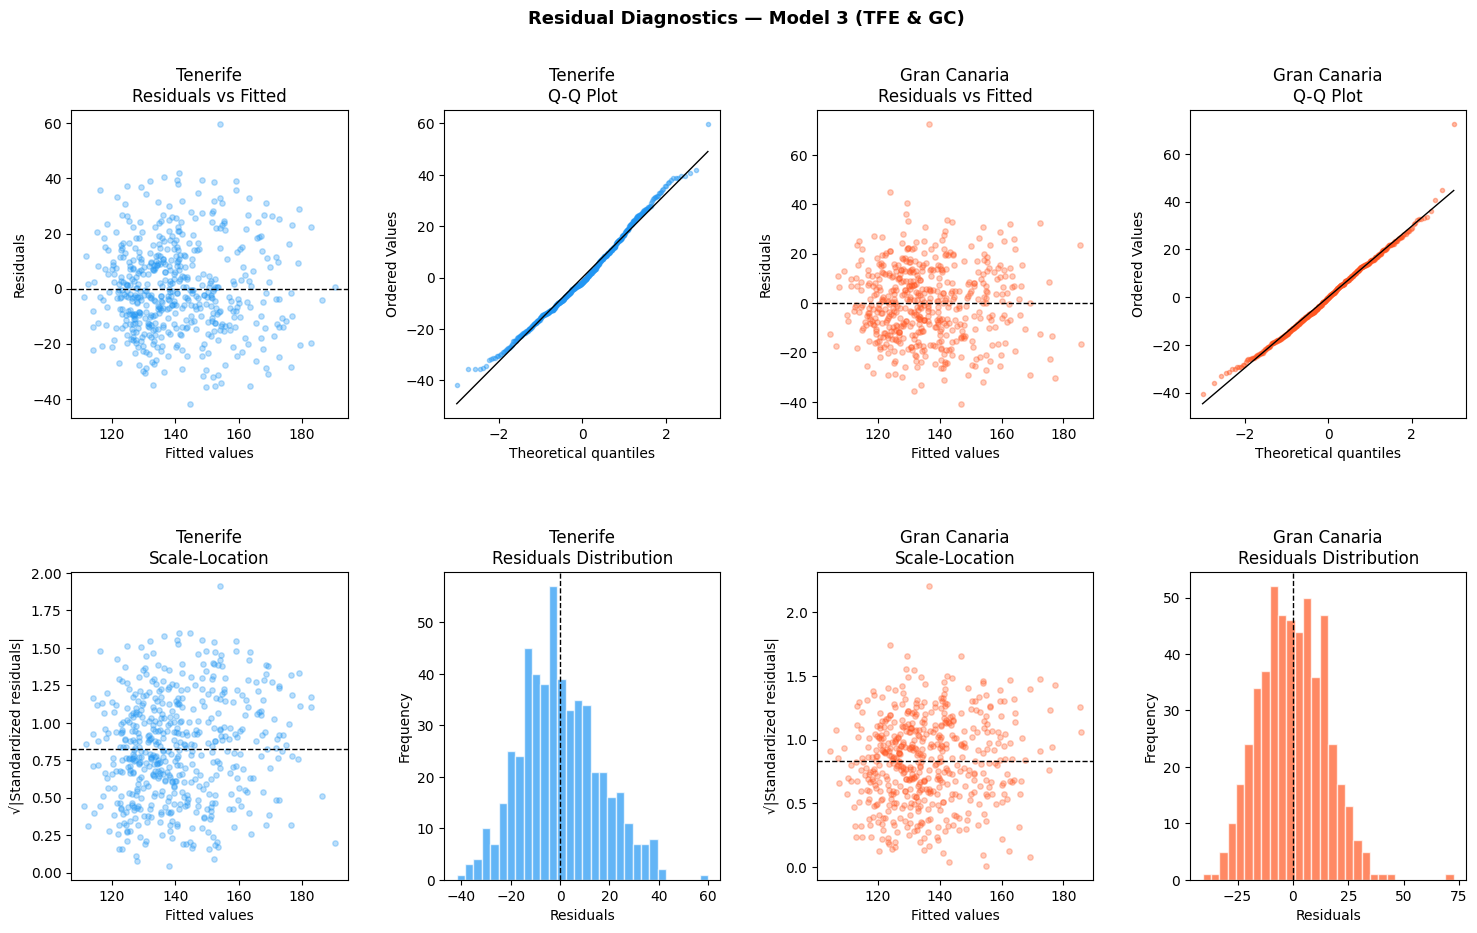

In [13]:
print("=" * 60)
print("DIAGNOSTICS — Model 3")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(18, 10), gridspec_kw={"hspace": 0.5, "wspace": 0.35})
fig.suptitle("Residual Diagnostics — Model 3 (TFE & GC)", fontsize=13, fontweight="bold")

for col, island in enumerate(ISLANDS):
    d = df[df["island"] == island].copy()
    d = d.sort_values("week_start")
    d["deaths_lag1"] = d["deaths_week"].shift(1)
    d = d.dropna(subset=["calima_ordinal", "deaths_week", "deaths_lag1",
                          "temp_c_mean", "Q_1", "Q_2", "Q_3"])

    model  = results_m3[island]
    fitted = model.fittedvalues
    resid  = model.resid
    std_resid = resid / resid.std()

    title_prefix = island.replace("_", " ").title()

    # Plot 1: Residuals vs Fitted
    ax = axes[0, col * 2]
    ax.scatter(fitted, resid, alpha=0.3, s=15, color=COLORS[island])
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"{title_prefix}\nResiduals vs Fitted")

    # Plot 2: Q-Q plot
    ax = axes[0, col * 2 + 1]
    scipy_stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix}\nQ-Q Plot")
    ax.get_lines()[0].set(markersize=3, alpha=0.4, color=COLORS[island])
    ax.get_lines()[1].set(color="black", linewidth=1)

    # Plot 3: Scale-Location
    ax = axes[1, col * 2]
    ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=15, color=COLORS[island])
    ax.axhline(np.sqrt(np.abs(std_resid)).mean(), color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("√|Standardized residuals|")
    ax.set_title(f"{title_prefix}\nScale-Location")

    # Plot 4: Residuals histogram
    ax = axes[1, col * 2 + 1]
    ax.hist(resid, bins=30, color=COLORS[island], alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Residuals")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{title_prefix}\nResiduals Distribution")

    # Shapiro-Wilk
    stat, p = scipy_stats.shapiro(resid)
    print(f"── {title_prefix} — Shapiro-Wilk ──")
    print(f"  W = {stat:.4f}, p = {p:.4e}")
    normal = "Yes (p > 0.05)" if p > 0.05 else "No (p < 0.05)"
    print(f"  Normal: {normal}\n")
autosave_fig(FIG_DIR / "diagnostics_model3_tfe_gc.png")
plt.tight_layout()
plt.show()

## Model 3 — Diagnostics

### Residual diagnostics — Model 3

| Check | TFE | GC |
|---|---|---|
| Linearity (Residuals vs Fitted) | ✅ Random scatter around zero | ✅ Random scatter around zero |
| Homoscedasticity (Scale-Location) | ✅ Constant variance | ✅ Constant variance |
| Normality (Q-Q + Shapiro-Wilk) | ⚠️ W=0.9908, p=2.49e-03 | ⚠️ W=0.9915, p=4.56e-03 |
| Residuals distribution | ⚠️ Mild right skew, upper tail | ⚠️ Mild right skew, upper tail |

### Interpretation
- Linearity and homoscedasticity assumptions hold in both islands
- Shapiro-Wilk rejects normality in both cases — driven by mild tail deviation, not central body
- Q-Q plots confirm: central body fits the normal line well; left tail deviates slightly (GC more than TFE)
- W > 0.99 in both islands indicates **mild, not severe** departure from normality
- With n > 500, OLS estimates remain valid by the Central Limit Theorem

**Model 3 is structurally sound and suitable for interpretation and publication.**

In [14]:
# ── Export final dataset with deaths_lag1 ─────────────────────────────────
for island in ISLANDS:
    d = df[df["island"] == island].copy()
    d = d.sort_values("week_start")
    d["deaths_lag1"] = d["deaths_week"].shift(1)
    df.loc[df["island"] == island, "deaths_lag1"] = d["deaths_lag1"].values

OUTPUT = BASE / "data/processed/provinces/regression_tfe_gc_features_2016_2025.parquet"
df.to_parquet(OUTPUT, index=False)

print(f"Dataset exported: {OUTPUT}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Dataset exported: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\provinces\regression_tfe_gc_features_2016_2025.parquet
Shape: 1044 rows x 24 columns
Columns: ['week_start', 'year', 'island', 'deaths_week', 'temp_c_mean', 'tmax_c_mean', 'tmin_c_mean', 'humidity_mean', 'prec_sum', 'PM10', 'PM2.5', 'low_vis_any_days_week', 'vis_min_m_week', 'calima_proxy_score', 'calima_proxy_level', 'calima_ordinal', 'calima_lag1', 'calima_lag2', 'quarter', 'Q_1', 'Q_2', 'Q_3', 'Q_4', 'deaths_lag1']


In [16]:
# ── EXPORT: model_summary.csv + regression_comparison.csv ─────────────────

# ── 1. model_summary.csv ───────────────────────────────────────────────────
rows = []
for island in ISLANDS:
    m3 = results_m3[island]
    for predictor in m3.params.index:
        rows.append({
            "model":       "Model3",
            "island":      island,
            "predictor":   predictor,
            "beta":        round(m3.params[predictor], 4),
            "p_value":     m3.pvalues[predictor],
            "significant": m3.pvalues[predictor] < 0.05,
        })

df_summary = pd.DataFrame(rows)
save_table(df_summary, TAB_DIR / "model_summary.csv")


# ── 2. regression_comparison.csv ──────────────────────────────────────────
comp_rows = []
for island in ISLANDS:
    m1 = results[island]
    m3 = results_m3[island]
    comp_rows.append({
        "island":    island,
        "R2_M1":     round(m1.rsquared, 4),
        "R2_M3":     round(m3.rsquared, 4),
        "AdjR2_M1":  round(m1.rsquared_adj, 4),
        "AdjR2_M3":  round(m3.rsquared_adj, 4),
        "AIC_M1":    round(m1.aic, 2),
        "AIC_M3":    round(m3.aic, 2),
        "BIC_M1":    round(m1.bic, 2),
        "BIC_M3":    round(m3.bic, 2),
        "DW_M1":     round(durbin_watson(m1.resid), 4),
        "DW_M3":     round(durbin_watson(m3.resid), 4),
    })

df_comparison = pd.DataFrame(comp_rows)
save_table(df_comparison, TAB_DIR / "regression_comparison.csv")

Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\tables\model_summary.csv
Saved table -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\tables\regression_comparison.csv


WindowsPath('C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/ccaa/tables/regression_comparison.csv')